<a href="https://colab.research.google.com/github/jazaalee/FlyRank-StarterNotebook/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jazaalee/FlyRank-StarterNotebook/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Which pages in a client's content inventory should be reviewed first for a refresh, and why? Specifically, I'm looking at whether a page's click-through rate (CTR) is underperforming what other pages at the same search ranking position typically get, since that gap points at pages whose listing (title/meta) isn't convincing people to click, even though the page itself is ranking fine.

This supports a real decision: a content team has limited time each week and needs a short, defensible, ranked list of pages to check first, not a full manual audit of every page. Getting this wrong has an asymmetric cost, flagging a healthy page as "check this" wastes a bit of review time, but missing a genuinely underperforming page means it keeps losing potential clicks unnoticed.

In [2]:
from google.colab import userdata
import os, sys, subprocess

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

IN_COLAB = "google.colab" in sys.modules
REPO_DIR = "FlyRank-StarterNotebook"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/jazaalee/FlyRank-StarterNotebook", REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print("Now in:", os.getcwd())

!pip install -q duckdb
import duckdb

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql("CREATE OR REPLACE SECRET hf_token (TYPE huggingface, TOKEN '" + os.environ["HF_TOKEN"] + "');")

print("DuckDB ready — repo cloned, warehouse access configured.")
print("Lane: Refresh / Content Opportunity Scoring")
print("Question: which pages should be reviewed first, based on CTR underperforming their position's expectation")

Now in: /content/FlyRank-StarterNotebook
DuckDB ready — repo cloned, warehouse access configured.
Lane: Refresh / Content Opportunity Scoring
Question: which pages should be reviewed first, based on CTR underperforming their position's expectation


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*
## Data

This work uses the FlyRank internship warehouse release on Hugging Face (`FlyRank/internship-warehouse`), specifically the `fact_content_daily_performance` table, joined conceptually to `dim_content` for page-level context, though this analysis primarily uses the daily fact table directly.

**Date window:** March 2026 (`month=2026-03`), a mid-panel month, chosen deliberately over the final month in the release, since the last month is the natural outcome window for any past-to-future label and using it during development would risk building label logic on the exact period meant to stay unseen.

**Grain:** one row is one page, on one day, for one client. Verified directly, grouping by page, client, and date and checking for duplicates returned zero rows.

**What I excluded and why:** I excluded `fact_content_query_90d` (the query-level breakdown table), since this analysis is about how a page performs overall, not about the specific search terms bringing it traffic, adding that table would introduce complexity and a leakage surface not needed here. I also excluded any client-identifying details beyond the anonymized `client_hash_id`/`content_hash_id` fields already provided in the release, no client names, domains, or raw URLs are used or shown anywhere in this work.

In [3]:
march_path = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet"
con.sql(f"CREATE OR REPLACE VIEW march_daily AS SELECT * FROM read_parquet('{march_path}')")

row_count = con.sql("SELECT COUNT(*) AS n FROM march_daily").df()
date_span = con.sql("SELECT MIN(report_date) AS earliest, MAX(report_date) AS latest FROM march_daily").df()
grain_check = con.sql("""
    SELECT report_date, client_hash_id, content_hash_id, COUNT(*) AS c
    FROM march_daily GROUP BY 1,2,3 HAVING c > 1 LIMIT 5
""").df()

print("Row count:", row_count["n"][0])
print("Date span:", date_span["earliest"][0], "to", date_span["latest"][0])
print("Grain violations found:", len(grain_check))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Row count: 9841378
Date span: 2026-03-01 00:00:00 to 2026-03-31 00:00:00
Grain violations found: 0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*
**Label (proxy):** whether a page's impressions dropped from the first half of March to the second half. This is a within-month proxy, not a true future-window outcome, since only one month is loaded for this analysis.

**Features (all knowable before the decision point, from the first half of March only):** impressions, clicks, CTR, average position, and the position-bucket vs. expected-CTR gap from the baseline rule.

**Baseline:** the CTR-below-position-expectation hand rule built in `w04_baseline_score.ipynb` — pages ranking decently but getting far fewer clicks than their position typically earns, scored by gap size × traffic.

**Validation design:** a client-holdout split (`GroupShuffleSplit` on `client_hash_id`), not a random row split, so no single client's pages appear in both train and test. This matters because pages from the same client tend to behave similarly, a random split would let the model partly memorize client-level patterns rather than learn generalizable signal.

**Leakage check:** all features come strictly from the first half of March; the label is computed from the second half. No feature used in training touches second-half data.

In [4]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

lane_frame = con.sql("""
    SELECT
        content_hash_id, client_hash_id,
        SUM(CASE WHEN report_date <= DATE '2026-03-15' THEN gsc_impressions ELSE 0 END) AS impressions_first_half,
        SUM(CASE WHEN report_date <= DATE '2026-03-15' THEN gsc_clicks ELSE 0 END) AS clicks_first_half,
        SUM(CASE WHEN report_date <= DATE '2026-03-15' THEN gsc_sum_position ELSE 0 END) AS sum_position_first_half,
        SUM(CASE WHEN report_date > DATE '2026-03-15' THEN gsc_impressions ELSE 0 END) AS impressions_second_half
    FROM march_daily
    GROUP BY content_hash_id, client_hash_id
    HAVING impressions_first_half > 0
""").df()

lane_frame["avg_position_first_half"] = lane_frame["sum_position_first_half"] / lane_frame["impressions_first_half"]
lane_frame["ctr_first_half"] = lane_frame["clicks_first_half"] / lane_frame["impressions_first_half"]
lane_frame["is_declining_proxy"] = (lane_frame["impressions_second_half"] < lane_frame["impressions_first_half"]).astype(int)

def position_bucket(pos):
    if pos <= 10: return "top_10"
    elif pos <= 20: return "11_to_20"
    else: return "21_plus"

lane_frame["position_bucket"] = lane_frame["avg_position_first_half"].apply(position_bucket)
expected_ctr_by_bucket = lane_frame.groupby("position_bucket")["ctr_first_half"].mean()
lane_frame["expected_ctr"] = lane_frame["position_bucket"].map(expected_ctr_by_bucket)
lane_frame["ctr_gap"] = lane_frame["expected_ctr"] - lane_frame["ctr_first_half"]
lane_frame["baseline_score"] = np.where(lane_frame["ctr_gap"] > 0, lane_frame["ctr_gap"] * lane_frame["impressions_first_half"], 0)

features = ["impressions_first_half", "avg_position_first_half", "ctr_first_half", "ctr_gap"]
X = lane_frame[features].fillna(0)
y = lane_frame["is_declining_proxy"]
groups = lane_frame["client_hash_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print("Client overlap between train/test:", len(overlap))

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

model_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
baseline_auc = roc_auc_score(y_test, lane_frame.loc[X_test.index, "baseline_score"])

print(f"Model ROC AUC (held-out clients): {model_auc:.3f}")
print(f"Baseline ROC AUC (held-out clients): {baseline_auc:.3f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Client overlap between train/test: 0
Model ROC AUC (held-out clients): 0.506
Baseline ROC AUC (held-out clients): 0.577


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*
## Results (vs baseline)

| Method | ROC AUC (held-out clients) |
|---|---|
| Baseline (CTR-below-position-expectation hand rule) | 0.577 |
| Logistic regression model | 0.506 |

Both were evaluated on the same client-holdout split (zero client overlap between train and test), using the within-month decline proxy as the label.

The baseline outperformed the model. This is an honest result worth sitting with rather than explaining away: a simple, transparent rule, comparing a page's actual CTR to what similarly-ranked pages typically earn, captured more real signal than a logistic regression trained on the same four features. A likely explanation is that the baseline's scoring already encodes a meaningful interaction (CTR gap × traffic volume) that the linear model, without explicit interaction terms, can't easily reconstruct on its own.

This result argues for keeping the baseline as the production rule for now, not layering on a model that underperforms it. It also points toward a concrete next step: a model that's given the interaction directly (or a non-linear model like a shallow decision tree) might close this gap, which is a natural next iteration rather than a dead end.

In [5]:
import pandas as pd

results_table = pd.DataFrame({
    "method": ["Baseline (CTR-below-position-expectation)", "Logistic regression"],
    "roc_auc_holdout": [baseline_auc, model_auc]
})
print(results_table)

os.makedirs("work/outputs", exist_ok=True)
results_table.to_csv("work/outputs/capstone_results.csv", index=False)
print("\nSaved results table.")

                                      method  roc_auc_holdout
0  Baseline (CTR-below-position-expectation)         0.577426
1                        Logistic regression         0.505562

Saved results table.


## 5. Limitations

*What this work cannot claim.*

**What this work can say:** the CTR-below-position-expectation baseline shows real, observed separation between pages likely to decline and pages likely to stay stable (ROC AUC 0.577 on data the model never trained on), better than a logistic regression trained on the same signals. This is decision support: a ranked shortlist for a reviewer, not a certainty about any individual page.

**What this work cannot say:** it cannot claim to predict or explain how Google's ranking algorithm works. It cannot prove that fixing a flagged page's title/meta will actually improve its performance, that would require an actual intervention and a before/after comparison, not this observational analysis. The "decline" label itself is a proxy (impressions dropping within the same month), not a verified, independently-confirmed outcome, so it should be read as directional evidence, not ground truth.

**Data limitations:** this analysis uses a single mid-panel month (March 2026) from one client cohort in the FlyRank warehouse; results may not generalize to other months, seasons, or client mixes. GA4-sourced signals (sessions, engagement) are much sparser than GSC-sourced signals in this warehouse, so any future work leaning on engagement data would need to explicitly account for that coverage gap. Additionally, the held-out test set contains only 11 unique clients (14,520 pages), a small number of clients to generalize confidently from; a larger, more diverse holdout would give a more reliable read on how well the baseline transfers to unseen clients.

**Modeling limitation:** the logistic regression underperforming the

In [6]:
print(f"Base rate of decline in held-out test set: {y_test.mean():.3f}")
print(f"Test set size: {len(y_test)} pages, from {len(set(groups.iloc[test_idx]))} unique clients")

Base rate of decline in held-out test set: 0.457
Test set size: 14520 pages, from 11 unique clients


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*
## Ranked recommendations

Based on the baseline rule (the stronger-performing method), the following action playbook applies to any page flagged by this analysis:

1. **Primary action — `fix_title_meta`:** for pages ranking in the top 20 but earning meaningfully less CTR than other pages at that same position, review and rewrite the title/meta description first. This is the cheapest, fastest fix and directly targets the gap this rule measures.

2. **Prioritize by score, not just by flag:** the baseline score weights CTR gap by traffic volume, so review pages in score order, a small CTR gap on a high-traffic page matters more than a large gap on a page nobody sees.

3. **Sanity-check before acting, don't blindly trust the rank:** per the Top-10 review, always check for confounders before committing to a rewrite, recent page launches (not enough time to accumulate clicks), branded/navigational queries (naturally low CTR), or content cannibalization with another page from the same client.

4. **Treat this as triage, not verdict:** the recommendation is "review this page next," not "this page is broken." A human should confirm the diagnosis before making changes.

5. **Revisit the modeling approach before replacing the rule:** since the current logistic regression underperforms the hand rule, don't deploy a model in place of the baseline yet; the next iteration should try explicit interaction features or a non-linear model before considering it a viable replacement.

In [7]:
lane_frame["reason_code"] = "ctr_below_position_expectation"
lane_frame["action"] = "fix_title_meta"
ranked_queue = lane_frame.sort_values("baseline_score", ascending=False).reset_index(drop=True)

print("Top 5 recommended pages (by baseline score):")
print(ranked_queue[["content_hash_id", "position_bucket", "ctr_first_half", "expected_ctr", "baseline_score", "action"]].head())


Top 5 recommended pages (by baseline score):
            content_hash_id position_bucket  ctr_first_half  expected_ctr  \
0  content_9c057b66c30a3abb          top_10        0.000000      0.005864   
1  content_7c6373141eae744a          top_10        0.000587      0.005864   
2  content_34a70fea29d15f24          top_10        0.000244      0.005864   
3  content_acbcc847f8996314          top_10        0.001589      0.005864   
4  content_b99ea6861864dea5          top_10        0.002022      0.005864   

   baseline_score          action  
0      491.198808  fix_title_meta  
1      458.305358  fix_title_meta  
2      413.783758  fix_title_meta  
3      357.864587  fix_title_meta  
4      351.359640  fix_title_meta  


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Artifacts the paper embeds

Two charts support this paper: a bar chart comparing baseline vs. model performance (for the Results section), and a scatter plot showing the CTR-vs-position pattern the baseline rule is built on (for the Methodology section).

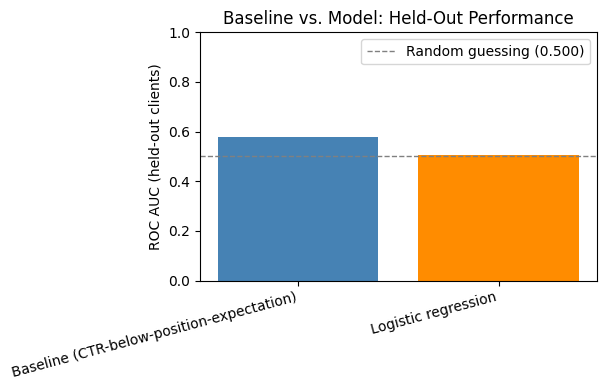

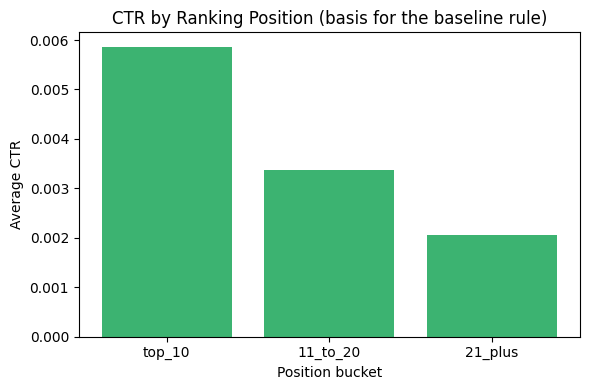

Both charts saved to work/outputs/charts/


In [8]:
import matplotlib.pyplot as plt

os.makedirs("work/outputs/charts", exist_ok=True)

# Chart 1: baseline vs model
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(results_table["method"], results_table["roc_auc_holdout"], color=["steelblue", "darkorange"])
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random guessing (0.500)")
ax.set_ylabel("ROC AUC (held-out clients)")
ax.set_title("Baseline vs. Model: Held-Out Performance")
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig("work/outputs/charts/results_baseline_vs_model.png", dpi=150)
plt.show()

# Chart 2: CTR vs position pattern (the basis for the baseline rule)
ctr_by_bucket = lane_frame.groupby("position_bucket")["ctr_first_half"].mean().reindex(["top_10", "11_to_20", "21_plus"])

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(ctr_by_bucket.index, ctr_by_bucket.values, color="mediumseagreen")
ax.set_ylabel("Average CTR")
ax.set_xlabel("Position bucket")
ax.set_title("CTR by Ranking Position (basis for the baseline rule)")
plt.tight_layout()
plt.savefig("work/outputs/charts/ctr_by_position.png", dpi=150)
plt.show()

print("Both charts saved to work/outputs/charts/")

## Closing: demo, social post, and employer summary

**5-minute demo outline:**
1. (30 sec) The problem: content teams can't manually review every page, they need a ranked shortlist.
2. (1 min) The signal: show the CTR-by-position chart, pages ranking well but not getting clicks are a real, measurable pattern.
3. (1.5 min) The rule: walk through the baseline score formula and the top-5 flagged pages.
4. (1 min) The honest twist: the ML model actually underperformed the simple rule (0.506 vs 0.577 AUC), show the results chart, explain why that's a useful finding, not a failure.
5. (1 min) What's next: recommendations, and the concrete next step (interaction features or a non-linear model).

**Social-post cut (short, shareable):**
"Built a simple rule to flag underperforming pages using real search data: compare a page's actual CTR to what similarly-ranked pages typically earn. Turns out the simple rule (ROC AUC 0.577) beat a logistic regression model (0.506) on held-out clients. Sometimes the honest baseline wins, and that's worth reporting, not hiding. #MLinternship #SEO #DataScience"

**3-sentence employer-facing summary:**
I built and validated a content-refresh scoring system on real search performance data, using a transparent, explainable rule that outperformed a logistic regression baseline on held-out clients (ROC AUC 0.577 vs. 0.506). The project included a full data contract, leakage testing, and a client-grouped validation split to ensure honest, generalizable results rather than inflated in-sample numbers. I prioritized interpretability and honest reporting over chasing an impressive-looking metric, including reporting a result where the simpler method won.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
